# Lifestyle Habits and Metabolic Health Awareness

**Statistical Techniques for Data Analytics, Individual CA1**
Higher Diploma in Data Analytics for Business, CCT College Dublin
Author: Michael David Hernandez Solorzano

The data comes from my own Google Forms survey (`Data_CA1.csv`). It was anonymised before saving: the timestamp and consent columns were removed and no names, emails or IDs were collected.

**Problem:** are people active enough to protect their metabolic health, and which habits go together with being active?
**Target variable:** `weekly_activity_min` (active days × minutes per day) and its binary version `meets_who` (at least 150 minutes per week, the WHO guideline for adults).

Sections follow the marking scheme:
1. Descriptive analysis
2. Visualisations
3. Outliers, confidence intervals and sampling
4. Inferential statistics (Bayes and normal distribution)
5. Correlation and chi-square

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 0. Loading and preparing the data

In [2]:
# the CSV sits next to the notebook on Moodle and in ../data/ in the repo
path = "Data_CA1.csv" if os.path.exists("Data_CA1.csv") else "../data/Data_CA1.csv"
df = pd.read_csv(path)

print(f"Rows: {df.shape[0]}, columns: {df.shape[1]}")
df.head()

Rows: 31, columns: 17


,age,gender,occupation,active_days,active_min_per_day,sitting_hours,sleep_hours,sugary_drinks_week,uses_tracker,height_cm,weight_band,waist_increased,heard_of_ir,last_blood_test,self_rated_health,diabetes_concern,would_use_tool
0,49,Male,Working full-time,7,70,8.0,8.0,0,True,169.0,80–89 kg,No,True,Within the last year,4,5,5
1,36,Female,Working full-time,5,100,10.0,7.0,7,False,158.0,50–59 kg,Yes,False,Within the last year,4,2,5
2,26,Female,Working full-time,4,40,9.0,8.0,2,True,168.0,70–79 kg,Yes,True,Within the last year,4,3,3
3,27,Male,Working full-time,5,50,8.0,8.0,3,True,178.0,80–89 kg,No,True,Within the last year,4,2,4
4,36,Male,Studying only,5,60,8.0,8.0,2,False,192.0,70–79 kg,No,True,1–2 years ago,4,1,3


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31 entries, 0 to 30
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 31 non-null     int64  
 1   gender              31 non-null     str    
 2   occupation          31 non-null     str    
 3   active_days         31 non-null     int64  
 4   active_min_per_day  31 non-null     int64  
 5   sitting_hours       31 non-null     float64
 6   sleep_hours         31 non-null     float64
 7   sugary_drinks_week  31 non-null     int64  
 8   uses_tracker        31 non-null     bool   
 9   height_cm           29 non-null     float64
 10  weight_band         30 non-null     str    
 11  waist_increased     30 non-null     str    
 12  heard_of_ir         31 non-null     bool   
 13  last_blood_test     31 non-null     str    
 14  self_rated_health   31 non-null     int64  
 15  diabetes_concern    31 non-null     int64  
 16  would_use_tool      3

In [4]:
# missing values: only the optional body measurement questions can be skipped
df.isna().sum()[df.isna().sum() > 0]

height_cm          2
weight_band        1
waist_increased    1
dtype: int64

### Derived columns

- `weekly_activity_min` = `active_days` × `active_min_per_day`. This is the target variable.
- `meets_who` = `weekly_activity_min` ≥ 150. Binary target, used for Bayes and chi-square.
- `bmi_approx` = weight ÷ height². Weight was asked in 10 kg bands (less sensitive than an exact number), so I use the midpoint of each band. It is only an approximation.
- `age_band` groups age for the plots.

In [5]:
df["weekly_activity_min"] = df["active_days"] * df["active_min_per_day"]
df["meets_who"] = df["weekly_activity_min"] >= 150

# midpoint of each weight band (open-ended bands use a value 5 kg past the edge)
weight_midpoints = {
    "Under 50 kg": 45, "50–59 kg": 54.5, "60–69 kg": 64.5, "70–79 kg": 74.5,
    "80–89 kg": 84.5, "90–99 kg": 94.5, "100–109 kg": 104.5, "110 kg or more": 115,
}
df["weight_mid_kg"] = df["weight_band"].map(weight_midpoints)
df["bmi_approx"] = df["weight_mid_kg"] / (df["height_cm"] / 100) ** 2

df["age_band"] = pd.cut(df["age"], bins=[17, 24, 34, 44, 54, 120],
                        labels=["18–24", "25–34", "35–44", "45–54", "55+"])

# every answered weight band must have a midpoint
assert df["weight_mid_kg"].isna().sum() == df["weight_band"].isna().sum()

df[["active_days", "active_min_per_day", "weekly_activity_min", "meets_who", "bmi_approx", "age_band"]].head()

,active_days,active_min_per_day,weekly_activity_min,meets_who,bmi_approx,age_band
0,7,70,490,True,29.585799,45–54
1,5,100,500,True,21.831437,35–44
2,4,40,160,True,26.395975,25–34
3,5,50,250,True,26.669612,25–34
4,5,60,300,True,20.209418,35–44


In [6]:
# sanity checks for impossible answers
print("Sitting + sleep over 24 hours:", ((df["sitting_hours"] + df["sleep_hours"]) > 24).sum())
print("Active days = 0 but minutes > 0:", ((df["active_days"] == 0) & (df["active_min_per_day"] > 0)).sum())
print("Active days > 0 but minutes = 0:", ((df["active_days"] > 0) & (df["active_min_per_day"] == 0)).sum())
print("More than 3 hours of activity per day:", (df["active_min_per_day"] > 180).sum())

Sitting + sleep over 24 hours: 0
Active days = 0 but minutes > 0: 0
Active days > 0 but minutes = 0: 1
More than 3 hours of activity per day: 1


## 1. Descriptive analysis

For every numeric column I calculate:

- **Central tendency:** mean $\bar{x} = \frac{1}{n}\sum x_i$, median (middle value) and mode (most common value). When the mean is far from the median the distribution is skewed, so the median is the better "typical" value.
- **Spread:** sample standard deviation $s = \sqrt{\frac{\sum (x_i - \bar{x})^2}{n-1}}$ and the interquartile range $IQR = Q_3 - Q_1$, which is not affected by extreme values.
- **Shape:** skewness (0 = symmetric, positive = long tail to the right) and excess kurtosis (0 = same tails as a normal distribution, positive = heavier tails).
- **Normality:** Shapiro-Wilk test. $H_0$: the data comes from a normal distribution. If $p < 0.05$ I reject $H_0$. Shapiro-Wilk is a good choice for small samples like this one.

In [7]:
num_cols = ["age", "active_days", "active_min_per_day", "weekly_activity_min", "sitting_hours",
            "sleep_hours", "sugary_drinks_week", "height_cm", "bmi_approx",
            "self_rated_health", "diabetes_concern", "would_use_tool"]

rows = []
for col in num_cols:
    s = df[col].dropna()
    w, p = stats.shapiro(s)
    rows.append({
        "column": col, "n": len(s),
        "mean": s.mean(), "median": s.median(), "mode": s.mode().iloc[0],
        "std": s.std(), "IQR": s.quantile(0.75) - s.quantile(0.25),
        "min": s.min(), "max": s.max(),
        "skew": s.skew(), "kurtosis": s.kurt(),
        "shapiro_p": p, "normal (p > 0.05)": p > 0.05,
    })

desc = pd.DataFrame(rows).set_index("column")
desc.round(3)

,n,mean,median,mode,std,IQR,min,max,skew,kurtosis,shapiro_p,normal (p > 0.05)
column,,,,,,,,,,,,
age,31,38.000,36.000,27.000,10.721,13.000,26.000,69.0,1.268,1.352,0.003,False
active_days,31,4.258,5.000,5.000,2.033,2.000,0.000,7.0,-0.528,-0.259,0.010,False
active_min_per_day,31,70.548,60.000,60.000,87.909,37.500,0.000,500.0,4.111,19.999,0.000,False
weekly_activity_min,31,338.000,250.000,300.000,446.886,300.000,0.000,2500.0,3.984,19.115,0.000,False
sitting_hours,31,7.710,8.000,8.000,2.971,4.000,2.000,14.0,0.076,-0.196,0.651,True
sleep_hours,31,7.190,7.000,7.000,0.916,1.000,5.000,9.0,-0.605,0.209,0.004,False
sugary_drinks_week,31,2.129,1.000,0.000,2.802,3.000,0.000,10.0,1.677,2.466,0.000,False
height_cm,29,170.517,169.000,169.000,11.372,13.000,150.000,194.0,0.277,-0.009,0.257,True
bmi_approx,28,28.135,26.874,20.209,5.717,4.422,20.209,42.0,0.936,0.428,0.013,False


In [8]:
# which columns are clearly skewed? (|skew| > 1 is usually called highly skewed)
for col, row in desc.iterrows():
    if abs(row["skew"]) > 1:
        side = "right" if row["skew"] > 0 else "left"
        print(f"{col}: skew = {row['skew']:.2f} ({side} tail), mean = {row['mean']:.1f} vs median = {row['median']:.1f}")

age: skew = 1.27 (right tail), mean = 38.0 vs median = 36.0
active_min_per_day: skew = 4.11 (right tail), mean = 70.5 vs median = 60.0
weekly_activity_min: skew = 3.98 (right tail), mean = 338.0 vs median = 250.0
sugary_drinks_week: skew = 1.68 (right tail), mean = 2.1 vs median = 1.0
would_use_tool: skew = -1.06 (left tail), mean = 3.9 vs median = 4.0


### Categorical columns

For categories the mean has no meaning, so I use counts, percentages and the mode.

In [9]:
cat_cols = ["gender", "occupation", "age_band", "uses_tracker", "weight_band",
            "waist_increased", "heard_of_ir", "last_blood_test", "meets_who"]

for col in cat_cols:
    counts = df[col].value_counts(dropna=False)
    table = pd.DataFrame({"count": counts, "percent": (counts / len(df) * 100).round(1)})
    print(f"\n{col} (mode: {df[col].mode().iloc[0]})")
    print(table.to_string())


gender (mode: Male)
        count  percent
gender                
Male       18     58.1
Female     13     41.9

occupation (mode: Working full-time)
                      count  percent
occupation                          
Working full-time        14     45.2
Studying and working     10     32.3
Studying only             3      9.7
Working part-time         3      9.7
Not working               1      3.2

age_band (mode: 25–34)
          count  percent
age_band                
25–34        14     45.2
35–44        10     32.3
45–54         4     12.9
55+           3      9.7
18–24         0      0.0

uses_tracker (mode: True)
              count  percent
uses_tracker                
True             17     54.8
False            14     45.2

weight_band (mode: 70–79 kg)
                count  percent
weight_band                   
70–79 kg           10     32.3
80–89 kg            7     22.6
50–59 kg            3      9.7
90–99 kg            3      9.7
60–69 kg            3      9.7
1

## 2. Visualisations

Each plot was chosen for the type of data it shows: histograms and box plots for numeric variables, bar/count plots for categories and Likert scales, scatter plot and heatmap for relationships.

### Plot 1: Histogram of weekly activity (target)

A histogram shows the shape of a numeric variable. I added the mean, the median and the WHO guideline of 150 minutes. If the mean sits to the right of the median, the distribution is right-skewed.

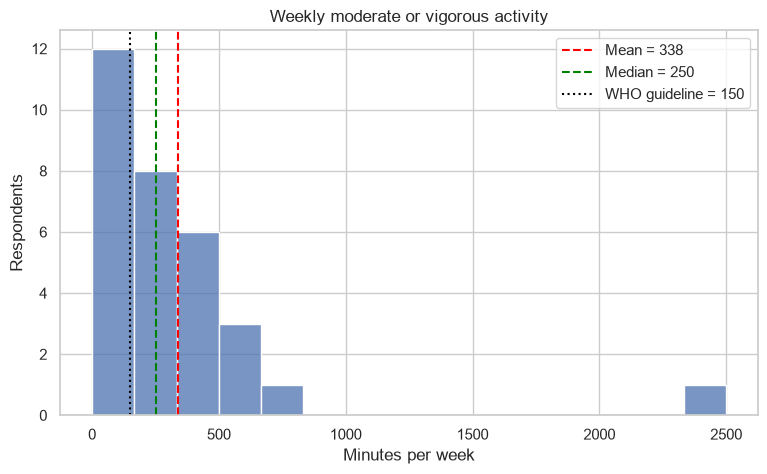

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["weekly_activity_min"], bins=15, ax=ax)
ax.axvline(df["weekly_activity_min"].mean(), color="red", linestyle="--", label=f"Mean = {df['weekly_activity_min'].mean():.0f}")
ax.axvline(df["weekly_activity_min"].median(), color="green", linestyle="--", label=f"Median = {df['weekly_activity_min'].median():.0f}")
ax.axvline(150, color="black", linestyle=":", label="WHO guideline = 150")
ax.set(title="Weekly moderate or vigorous activity", xlabel="Minutes per week", ylabel="Respondents")
ax.legend()
plt.show()

### Plot 2: Histogram of sleep with a normal curve

The curve is the normal density $f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$ using the sample mean and standard deviation. If the bars follow the curve, the normal model is reasonable for sleep (this matters for section 4).

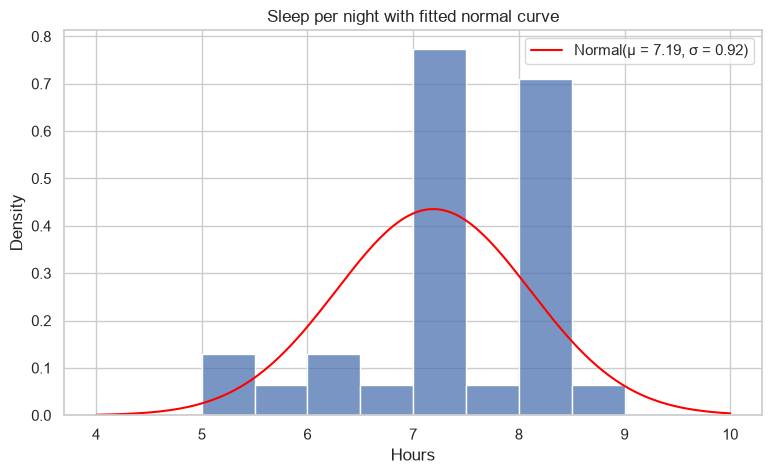

In [11]:
mu_sleep, sd_sleep = df["sleep_hours"].mean(), df["sleep_hours"].std()

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(df["sleep_hours"], bins=8, stat="density", ax=ax)
x = np.linspace(df["sleep_hours"].min() - 1, df["sleep_hours"].max() + 1, 200)
ax.plot(x, stats.norm.pdf(x, mu_sleep, sd_sleep), color="red", label=f"Normal(μ = {mu_sleep:.2f}, σ = {sd_sleep:.2f})")
ax.set(title="Sleep per night with fitted normal curve", xlabel="Hours", ylabel="Density")
ax.legend()
plt.show()

### Plot 3: Q-Q plot of sleep

A Q-Q plot compares the sample quantiles with the quantiles of a normal distribution. Points on the line mean the data is close to normal. The "steps" appear because people answer in round numbers (7, 7.5, 8).

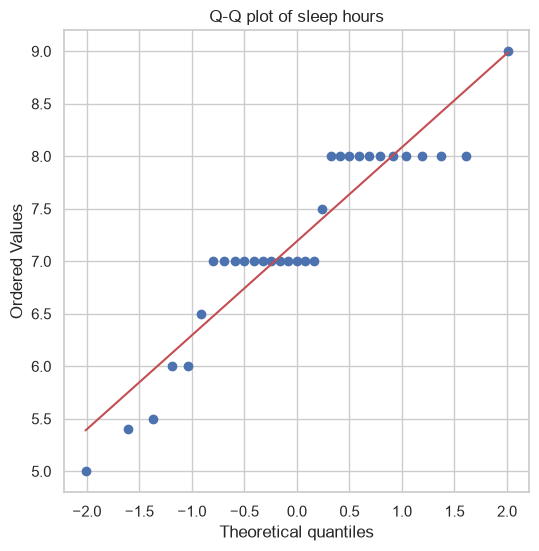

In [12]:
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(df["sleep_hours"], dist="norm", plot=ax)
ax.set_title("Q-Q plot of sleep hours")
plt.show()

### Plot 4: Box plot of sitting hours by occupation

A box plot shows the median, the quartiles and the outliers (points beyond 1.5 × IQR). The individual answers are drawn on top because some groups are very small.

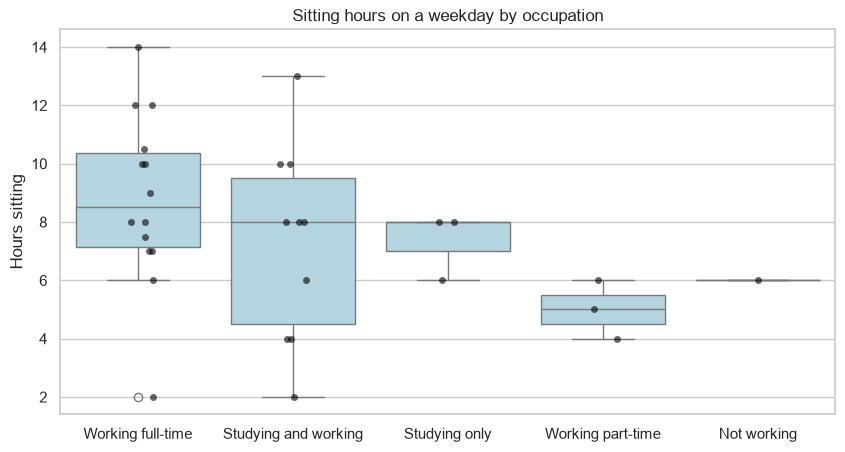

In [13]:
order = df["occupation"].value_counts().index

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x="occupation", y="sitting_hours", order=order, color="lightblue", ax=ax)
sns.stripplot(data=df, x="occupation", y="sitting_hours", order=order, color="black", alpha=0.6, ax=ax)
ax.set(title="Sitting hours on a weekday by occupation", xlabel="", ylabel="Hours sitting")
plt.show()

### Plot 5: Box plot of weekly activity by tracker use

Compares the target between people who use a fitness tracker and people who do not.

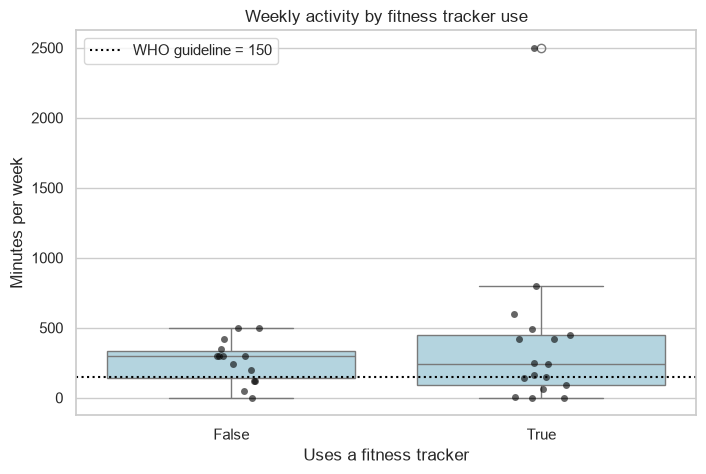

,count,mean,median,std
uses_tracker,,,,
False,14,264.3,300.0,154.4
True,17,398.7,240.0,588.6


In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="uses_tracker", y="weekly_activity_min", color="lightblue", ax=ax)
sns.stripplot(data=df, x="uses_tracker", y="weekly_activity_min", color="black", alpha=0.6, ax=ax)
ax.axhline(150, color="black", linestyle=":", label="WHO guideline = 150")
ax.set(title="Weekly activity by fitness tracker use", xlabel="Uses a fitness tracker", ylabel="Minutes per week")
ax.legend()
plt.show()

df.groupby("uses_tracker")["weekly_activity_min"].agg(["count", "mean", "median", "std"]).round(1)

### Plot 6: Likert scale answers

Likert answers are ordinal (1 to 5), so a bar chart of counts is clearer than a histogram, and the median is a better summary than the mean.

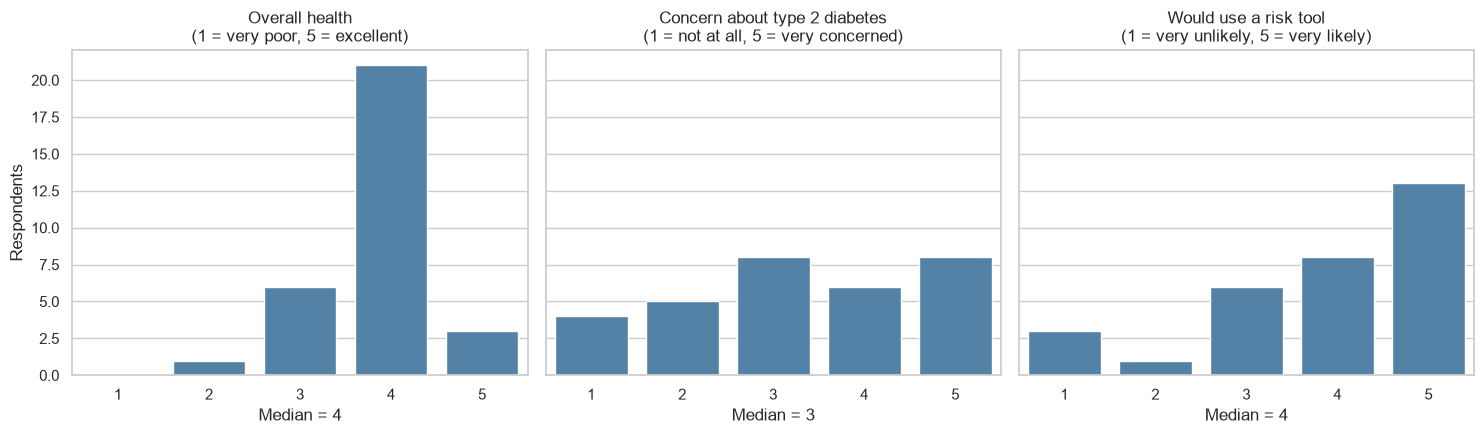

In [15]:
likert = {
    "self_rated_health": "Overall health\n(1 = very poor, 5 = excellent)",
    "diabetes_concern": "Concern about type 2 diabetes\n(1 = not at all, 5 = very concerned)",
    "would_use_tool": "Would use a risk tool\n(1 = very unlikely, 5 = very likely)",
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (col, title) in zip(axes, likert.items()):
    sns.countplot(data=df, x=col, order=[1, 2, 3, 4, 5], color="steelblue", ax=ax)
    ax.set(title=title, xlabel=f"Median = {df[col].median():.0f}", ylabel="Respondents")
plt.tight_layout()
plt.show()

### Plot 7: Scatter plot of sitting hours vs weekly activity

A scatter plot shows the relationship between two numeric variables. The line is the least squares regression line and the shaded area is its 95% confidence band.

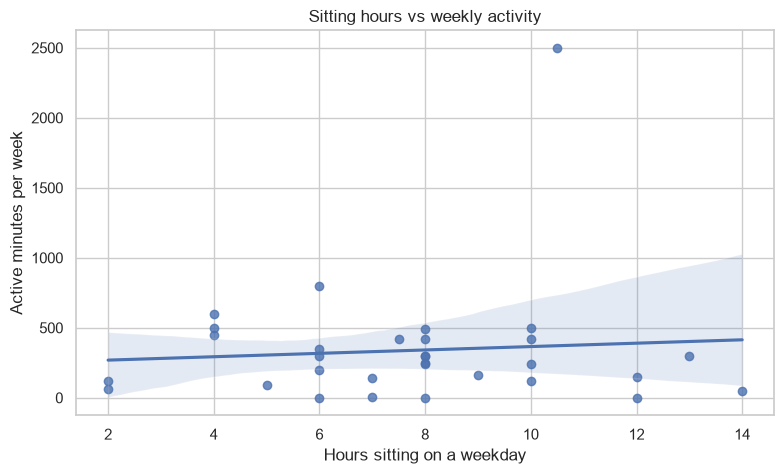

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.regplot(data=df, x="sitting_hours", y="weekly_activity_min", ax=ax)
ax.set(title="Sitting hours vs weekly activity", xlabel="Hours sitting on a weekday", ylabel="Active minutes per week")
plt.show()

### Plot 8: Correlation heatmap

I use Spearman's rank correlation here because several variables are skewed or ordinal (Likert), and Spearman does not assume normality or a straight-line relationship. Values go from −1 to +1.

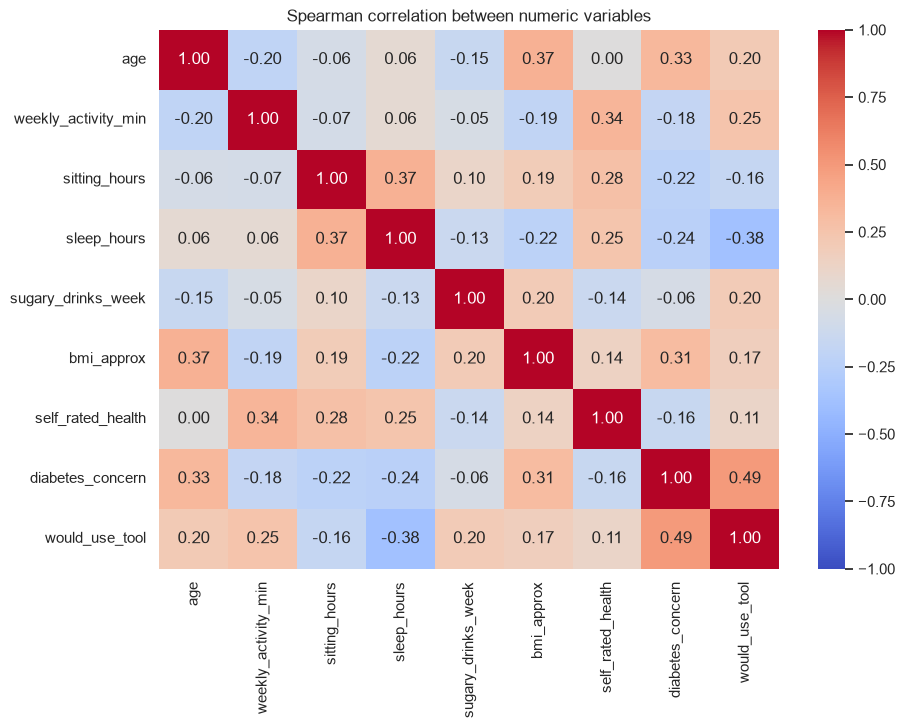

In [17]:
corr_cols = ["age", "weekly_activity_min", "sitting_hours", "sleep_hours", "sugary_drinks_week",
             "bmi_approx", "self_rated_health", "diabetes_concern", "would_use_tool"]

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(method="spearman"), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation between numeric variables")
plt.show()

### Plot 9: Awareness of insulin resistance by last blood test

A grouped count plot compares two categorical variables.

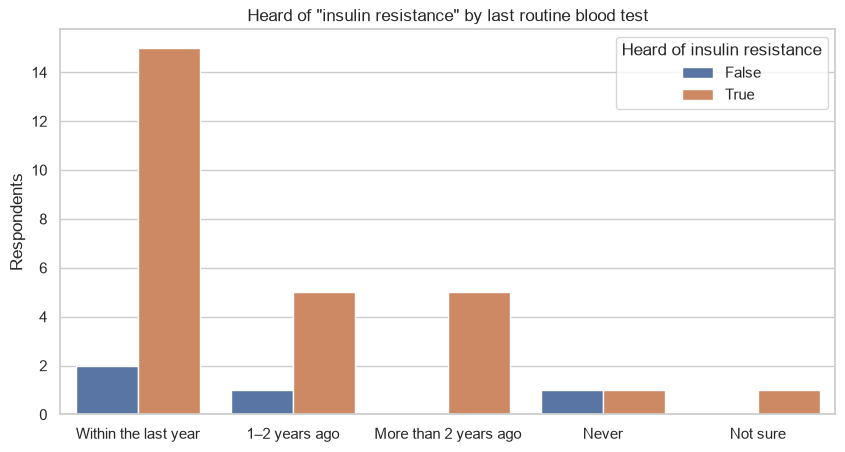

In [18]:
test_order = ["Within the last year", "1–2 years ago", "More than 2 years ago", "Never", "Not sure"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="last_blood_test", hue="heard_of_ir", order=test_order, ax=ax)
ax.set(title='Heard of "insulin resistance" by last routine blood test', xlabel="", ylabel="Respondents")
ax.legend(title="Heard of insulin resistance")
plt.show()

## 3. Outliers

Two common rules:

- **IQR rule:** a value is an outlier if it is below $Q_1 - 1.5 \times IQR$ or above $Q_3 + 1.5 \times IQR$. It works for skewed data because quartiles are not pulled by extreme values.
- **Z-score rule:** $z = \frac{x - \bar{x}}{s}$, outlier if $|z| > 3$. It assumes the data is roughly normal, and the outlier itself inflates $s$, so it can miss outliers in small samples.

In [19]:
def iqr_bounds(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

outlier_cols = ["weekly_activity_min", "sitting_hours", "sleep_hours"]

for col in outlier_cols:
    low, high = iqr_bounds(df[col])
    iqr_out = df.loc[(df[col] < low) | (df[col] > high), col]
    z = (df[col] - df[col].mean()) / df[col].std()
    z_out = df.loc[z.abs() > 3, col]
    print(f"{col}")
    print(f"  IQR bounds: [{low:.1f}, {high:.1f}] -> {len(iqr_out)} outlier(s): {sorted(iqr_out.tolist())}")
    print(f"  |z| > 3            -> {len(z_out)} outlier(s): {sorted(z_out.tolist())}")

weekly_activity_min
  IQR bounds: [-330.0, 870.0] -> 1 outlier(s): [2500]
  |z| > 3            -> 1 outlier(s): [2500]
sitting_hours
  IQR bounds: [0.0, 16.0] -> 0 outlier(s): []
  |z| > 3            -> 0 outlier(s): []
sleep_hours
  IQR bounds: [5.5, 9.5] -> 2 outlier(s): [5.0, 5.4]
  |z| > 3            -> 0 outlier(s): []


In [20]:
# the rows flagged by the IQR rule on the target
low, high = iqr_bounds(df["weekly_activity_min"])
is_outlier = (df["weekly_activity_min"] < low) | (df["weekly_activity_min"] > high)
df.loc[is_outlier, ["age", "occupation", "active_days", "active_min_per_day", "weekly_activity_min", "sitting_hours", "sleep_hours"]]

,age,occupation,active_days,active_min_per_day,weekly_activity_min,sitting_hours,sleep_hours
7,30,Working full-time,5,500,2500,10.5,5.4


### With vs without outliers

`df_no_outliers` removes the rows flagged by the IQR rule on the target. The table compares the same statistics for both datasets.

In [21]:
df_no_outliers = df[~is_outlier].copy()

def summary(s):
    return {"n": len(s), "mean": s.mean(), "median": s.median(), "std": s.std(),
            "skew": s.skew(), "kurtosis": s.kurt(), "shapiro_p": stats.shapiro(s)[1]}

compare = pd.DataFrame({
    "with outliers": summary(df["weekly_activity_min"]),
    "without outliers": summary(df_no_outliers["weekly_activity_min"]),
})
compare["change %"] = (compare["without outliers"] / compare["with outliers"] - 1) * 100
# a percentage change makes no sense for n or for a p-value
compare.loc[["n", "shapiro_p"], "change %"] = np.nan
compare.round(3)

,with outliers,without outliers,change %
n,31.000,30.000,NaN
mean,338.000,265.933,-21.321
median,250.000,245.000,-2.000
std,446.886,200.099,-55.224
skew,3.984,0.624,-84.333
kurtosis,19.115,0.131,-99.316
shapiro_p,0.000,0.155,NaN


### Plot 10: Target with and without outliers

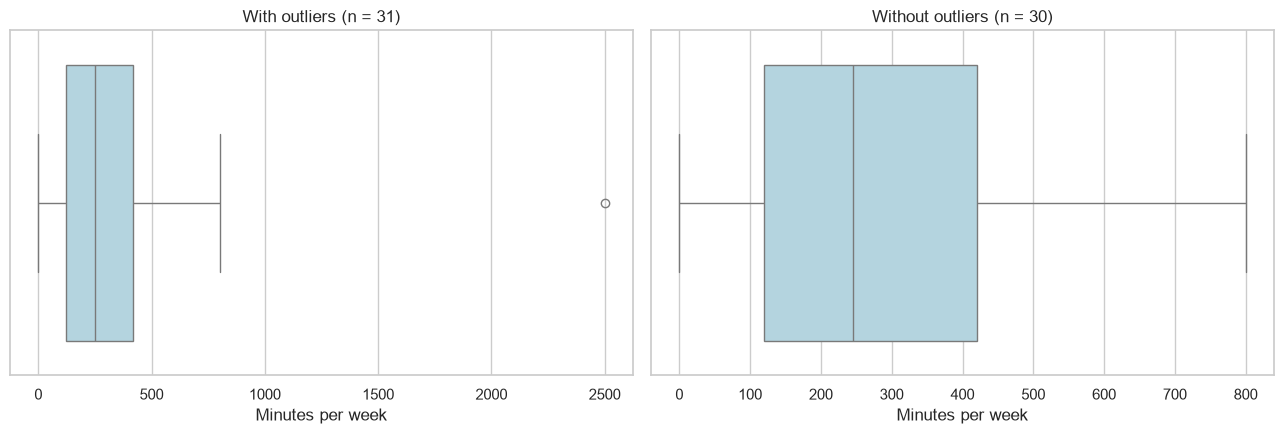

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(x=df["weekly_activity_min"], color="lightblue", ax=axes[0])
axes[0].set(title=f"With outliers (n = {len(df)})", xlabel="Minutes per week")
sns.boxplot(x=df_no_outliers["weekly_activity_min"], color="lightblue", ax=axes[1])
axes[1].set(title=f"Without outliers (n = {len(df_no_outliers)})", xlabel="Minutes per week")
plt.tight_layout()
plt.show()

### Confidence intervals

My respondents are a sample, so the sample mean is only an estimate of the population mean. A 95% confidence interval gives a range for it:

$$\bar{x} \pm t_{0.975,\,n-1} \times \frac{s}{\sqrt{n}}$$

I use the t distribution (not z) because the sample is small and the population standard deviation is unknown.

In [23]:
def mean_ci(s, confidence=0.95):
    s = s.dropna()
    n = len(s)
    se = s.std() / np.sqrt(n)                       # standard error of the mean
    margin = stats.t.ppf((1 + confidence) / 2, df=n - 1) * se
    return s.mean(), s.mean() - margin, s.mean() + margin

ci_rows = []
for label, data in [("with outliers", df), ("without outliers", df_no_outliers)]:
    for col in ["weekly_activity_min", "sleep_hours", "sitting_hours"]:
        mean, lo, hi = mean_ci(data[col])
        ci_rows.append({"dataset": label, "column": col, "mean": mean, "ci_low": lo, "ci_high": hi, "width": hi - lo})

pd.DataFrame(ci_rows).round(2)

,dataset,column,mean,ci_low,ci_high,width
0,with outliers,weekly_activity_min,338.00,174.08,501.92,327.84
1,with outliers,sleep_hours,7.19,6.85,7.53,0.67
2,with outliers,sitting_hours,7.71,6.62,8.80,2.18
3,without outliers,weekly_activity_min,265.93,191.22,340.65,149.44
4,without outliers,sleep_hours,7.25,6.93,7.57,0.65
5,without outliers,sitting_hours,7.62,6.51,8.73,2.22


### Sampling: bootstrap

The t interval assumes the sample mean is roughly normal, which is doubtful for a skewed variable with a small n. The bootstrap does not need that assumption: I resample my own data with replacement 10,000 times, calculate the mean each time, and take the 2.5th and 97.5th percentiles of those means.

In [24]:
rng = np.random.default_rng(42)

def bootstrap_means(s, n_resamples=10_000):
    values = s.dropna().to_numpy()
    samples = rng.choice(values, size=(n_resamples, len(values)), replace=True)
    return samples.mean(axis=1)

boot_with = bootstrap_means(df["weekly_activity_min"])
boot_without = bootstrap_means(df_no_outliers["weekly_activity_min"])

for label, boot in [("with outliers", boot_with), ("without outliers", boot_without)]:
    lo, hi = np.percentile(boot, [2.5, 97.5])
    print(f"Bootstrap 95% CI for mean weekly activity ({label}): [{lo:.1f}, {hi:.1f}]")

Bootstrap 95% CI for mean weekly activity (with outliers): [213.8, 512.5]
Bootstrap 95% CI for mean weekly activity (without outliers): [197.9, 337.9]


### Plot 11: Bootstrap distribution of the mean

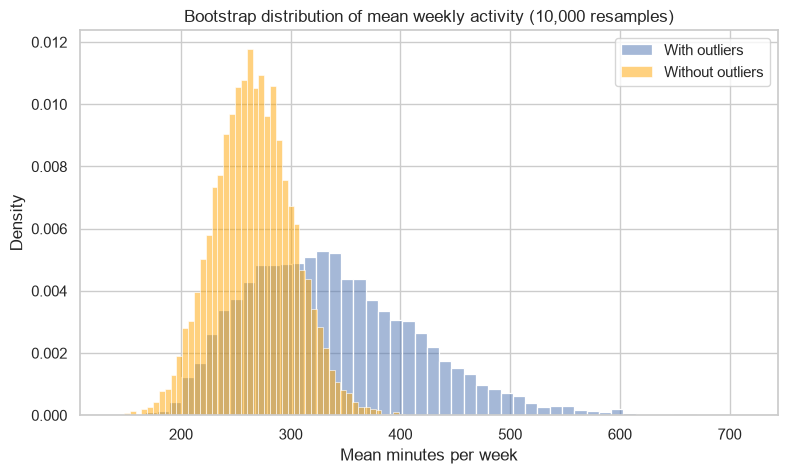

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(boot_with, bins=50, stat="density", alpha=0.5, label="With outliers", ax=ax)
sns.histplot(boot_without, bins=50, stat="density", alpha=0.5, color="orange", label="Without outliers", ax=ax)
ax.set(title="Bootstrap distribution of mean weekly activity (10,000 resamples)", xlabel="Mean minutes per week")
ax.legend()
plt.show()

## 4. Inferential statistics

### 4.1 Bayes' theorem: does using a tracker change the probability of meeting the WHO guideline?

- $A$ = meets the WHO guideline (`meets_who`)
- $B$ = uses a fitness tracker (`uses_tracker`)

$$P(A \mid B) = \frac{P(B \mid A)\,P(A)}{P(B)} \qquad P(B) = P(B \mid A)P(A) + P(B \mid \neg A)P(\neg A)$$

- **Prior** $P(A)$: probability of meeting the guideline before knowing anything else about the person.
- **Likelihood** $P(B \mid A)$: share of tracker users among people who meet the guideline.
- **Posterior** $P(A \mid B)$: updated probability once I know the person uses a tracker.

In [26]:
pd.crosstab(df["meets_who"], df["uses_tracker"], margins=True, margins_name="Total")

uses_tracker,False,True,Total
meets_who,,,
False,4,6,10
True,10,11,21
Total,14,17,31


In [27]:
p_A = df["meets_who"].mean()                                         # prior
p_not_A = 1 - p_A
p_B_given_A = df.loc[df["meets_who"], "uses_tracker"].mean()         # likelihood
p_B_given_not_A = df.loc[~df["meets_who"], "uses_tracker"].mean()

p_B = p_B_given_A * p_A + p_B_given_not_A * p_not_A                  # law of total probability
posterior = p_B_given_A * p_A / p_B                                  # Bayes' theorem

# same calculation for people without a tracker
posterior_no_tracker = (1 - p_B_given_A) * p_A / (1 - p_B)

print(f"Prior       P(meets WHO)                  = {p_A:.3f}")
print(f"Likelihood  P(tracker | meets WHO)        = {p_B_given_A:.3f}")
print(f"            P(tracker | does not meet)    = {p_B_given_not_A:.3f}")
print(f"Marginal    P(tracker)                    = {p_B:.3f}")
print(f"Posterior   P(meets WHO | tracker)        = {posterior:.3f}")
print(f"Posterior   P(meets WHO | no tracker)     = {posterior_no_tracker:.3f}")

# check against the direct count from the table
direct = df.loc[df["uses_tracker"], "meets_who"].mean()
print(f"\nDirect count P(meets WHO | tracker)       = {direct:.3f}")
print(f"Change from prior to posterior            = {(posterior - p_A) * 100:+.1f} percentage points")

Prior       P(meets WHO)                  = 0.677
Likelihood  P(tracker | meets WHO)        = 0.524
            P(tracker | does not meet)    = 0.600
Marginal    P(tracker)                    = 0.548
Posterior   P(meets WHO | tracker)        = 0.647
Posterior   P(meets WHO | no tracker)     = 0.714

Direct count P(meets WHO | tracker)       = 0.647
Change from prior to posterior            = -3.0 percentage points


### 4.2 Normal distribution: probability of sleeping less than 7 hours

Sleep is standardised with $z = \frac{x - \mu}{\sigma}$, which gives a variable with mean 0 and standard deviation 1. Then $P(\text{sleep} < 7) = \Phi\left(\frac{7 - \mu}{\sigma}\right)$, where $\Phi$ is the standard normal CDF (`scipy.stats.norm.cdf`, the Python version of `pnorm`). 7 hours is the minimum usually recommended for adults.

In [28]:
df["sleep_z"] = (df["sleep_hours"] - mu_sleep) / sd_sleep
print(f"sleep_z: mean = {df['sleep_z'].mean():.3f}, std = {df['sleep_z'].std():.3f}")

z_7 = (7 - mu_sleep) / sd_sleep
p_short_sleep = stats.norm.cdf(z_7)

print(f"\nz for 7 hours                    = {z_7:.3f}")
print(f"P(sleep < 7) from normal model   = {p_short_sleep:.3f}")
print(f"P(sleep < 7) observed proportion = {(df['sleep_hours'] < 7).mean():.3f}")

sleep_z: mean = -0.000, std = 1.000

z for 7 hours                    = -0.208
P(sleep < 7) from normal model   = 0.418
P(sleep < 7) observed proportion = 0.194


### 4.3 Conditional probability with the normal model: P(sleep < 7 | sitting > 8 hours)

- $A$ = sleeps less than 7 hours
- $B$ = sits more than 8 hours on a weekday

Given $B$, the sample space is only the people who sit more than 8 hours, so I fit the normal model to the sleep of that group and use its own mean and standard deviation: $P(A \mid B) = \Phi\left(\frac{7 - \mu_B}{\sigma_B}\right)$. I compare it with the observed proportion $\frac{n(A \cap B)}{n(B)}$ and with the unconditional probability from 4.2.

In [29]:
group_B = df[df["sitting_hours"] > 8]
group_not_B = df[df["sitting_hours"] <= 8]

mu_B, sd_B = group_B["sleep_hours"].mean(), group_B["sleep_hours"].std()
mu_nB, sd_nB = group_not_B["sleep_hours"].mean(), group_not_B["sleep_hours"].std()

p_A_given_B = stats.norm.cdf(7, loc=mu_B, scale=sd_B)
p_A_given_not_B = stats.norm.cdf(7, loc=mu_nB, scale=sd_nB)

print(f"People sitting > 8 h: n = {len(group_B)}, mean sleep = {mu_B:.2f}, sd = {sd_B:.2f}")
print(f"People sitting ≤ 8 h: n = {len(group_not_B)}, mean sleep = {mu_nB:.2f}, sd = {sd_nB:.2f}")
print()
print(f"P(sleep < 7)                normal model = {p_short_sleep:.3f}")
print(f"P(sleep < 7 | sitting > 8)  normal model = {p_A_given_B:.3f}   observed = {(group_B['sleep_hours'] < 7).mean():.3f}")
print(f"P(sleep < 7 | sitting ≤ 8)  normal model = {p_A_given_not_B:.3f}   observed = {(group_not_B['sleep_hours'] < 7).mean():.3f}")

People sitting > 8 h: n = 10, mean sleep = 7.54, sd = 0.98
People sitting ≤ 8 h: n = 21, mean sleep = 7.02, sd = 0.86

P(sleep < 7)                normal model = 0.418
P(sleep < 7 | sitting > 8)  normal model = 0.291   observed = 0.100
P(sleep < 7 | sitting ≤ 8)  normal model = 0.489   observed = 0.238


### Plot 12: Normal curves of sleep for the two sitting groups

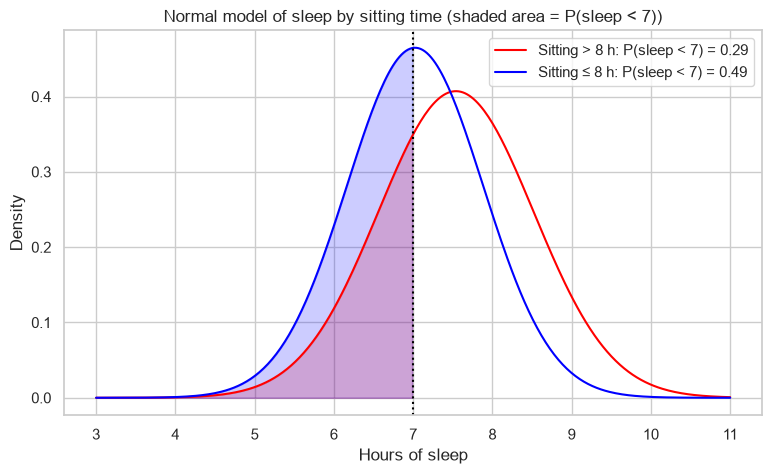

In [30]:
x = np.linspace(3, 11, 300)

fig, ax = plt.subplots(figsize=(9, 5))
for mu, sd, label, color in [(mu_B, sd_B, "Sitting > 8 h", "red"), (mu_nB, sd_nB, "Sitting ≤ 8 h", "blue")]:
    y = stats.norm.pdf(x, mu, sd)
    ax.plot(x, y, color=color, label=f"{label}: P(sleep < 7) = {stats.norm.cdf(7, mu, sd):.2f}")
    ax.fill_between(x, y, where=x < 7, color=color, alpha=0.2)
ax.axvline(7, color="black", linestyle=":")
ax.set(title="Normal model of sleep by sitting time (shaded area = P(sleep < 7))", xlabel="Hours of sleep", ylabel="Density")
ax.legend()
plt.show()

## 5. Correlation and chi-square

### 5.1 Correlation of numeric features with the target

- **Pearson** $r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$ measures a straight-line relationship and is sensitive to outliers.
- **Spearman** $\rho$ is Pearson applied to the ranks, so it handles skewed and ordinal data and is not pulled by one extreme value.

For both, $H_0$: no correlation. `active_days` and `active_min_per_day` are left out because the target is calculated from them.

In [31]:
target = "weekly_activity_min"
features = ["age", "sitting_hours", "sleep_hours", "sugary_drinks_week", "height_cm", "bmi_approx",
            "self_rated_health", "diabetes_concern", "would_use_tool"]

def correlations(data):
    rows = []
    for f in features:
        sub = data[[f, target]].dropna()
        r, p_r = stats.pearsonr(sub[f], sub[target])
        rho, p_rho = stats.spearmanr(sub[f], sub[target])
        rows.append({"feature": f, "n": len(sub), "pearson_r": r, "pearson_p": p_r,
                     "spearman_rho": rho, "spearman_p": p_rho})
    return pd.DataFrame(rows).set_index("feature").sort_values("spearman_rho", key=abs, ascending=False)

print("With outliers")
display(correlations(df).round(3))
print("Without outliers")
display(correlations(df_no_outliers).round(3))

With outliers


,n,pearson_r,pearson_p,spearman_rho,spearman_p
feature,,,,,
self_rated_health,31,0.421,0.018,0.344,0.058
would_use_tool,31,0.227,0.220,0.254,0.167
age,31,-0.229,0.216,-0.201,0.277
bmi_approx,28,0.301,0.120,-0.192,0.328
diabetes_concern,31,-0.292,0.111,-0.178,0.338
height_cm,29,-0.242,0.206,0.142,0.463
sitting_hours,31,0.080,0.667,-0.071,0.705
sleep_hours,31,-0.287,0.118,0.056,0.764
sugary_drinks_week,31,0.042,0.821,-0.051,0.787


Without outliers


,n,pearson_r,pearson_p,spearman_rho,spearman_p
feature,,,,,
bmi_approx,27,-0.335,0.088,-0.330,0.093
height_cm,28,0.172,0.381,0.269,0.166
self_rated_health,30,0.285,0.128,0.265,0.157
would_use_tool,30,0.184,0.329,0.210,0.266
age,30,-0.240,0.202,-0.170,0.369
sleep_hours,30,0.094,0.621,0.160,0.400
sitting_hours,30,-0.175,0.354,-0.144,0.449
sugary_drinks_week,30,-0.158,0.405,-0.129,0.496
diabetes_concern,30,-0.032,0.865,-0.101,0.595


### 5.2 Chi-square test of independence

For two categorical variables: $H_0$: the variables are independent.

$$\chi^2 = \sum \frac{(O - E)^2}{E} \qquad E = \frac{\text{row total} \times \text{column total}}{n}$$

The test needs expected counts of about 5 or more in each cell. With a small sample that often fails, so for every table I print the smallest expected count, and for 2×2 tables I also run **Fisher's exact test**, which is valid for small counts. **Cramér's V** $= \sqrt{\frac{\chi^2}{n \,(k-1)}}$ gives the strength of the association from 0 to 1.

In [32]:
def chi_square(row, col, data=df):
    table = pd.crosstab(data[row], data[col])
    chi2, p, dof, expected = stats.chi2_contingency(table, correction=False)
    n = table.to_numpy().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))

    print(f"{row} × {col}  (n = {n})")
    display(table)
    print(f"  chi2 = {chi2:.3f}, dof = {dof}, p = {p:.3f}, Cramér's V = {cramers_v:.3f}")
    print(f"  smallest expected count = {expected.min():.2f} "
          f"({(expected < 5).sum()} of {expected.size} cells below 5)")
    if table.shape == (2, 2):
        odds, p_fisher = stats.fisher_exact(table)
        print(f"  Fisher's exact test: odds ratio = {odds:.2f}, p = {p_fisher:.3f}")
    print()

chi_square("uses_tracker", "meets_who")
chi_square("occupation", "meets_who")
chi_square("last_blood_test", "heard_of_ir")

# waist question: keep only clear Yes / No answers
chi_square("waist_increased", "meets_who", data=df[df["waist_increased"].isin(["Yes", "No"])])

uses_tracker × meets_who  (n = 31)


meets_who,False,True
uses_tracker,,
False,4,10
True,6,11


  chi2 = 0.159, dof = 1, p = 0.690, Cramér's V = 0.072
  smallest expected count = 4.52 (1 of 4 cells below 5)
  Fisher's exact test: odds ratio = 0.73, p = 1.000

occupation × meets_who  (n = 31)


meets_who,False,True
occupation,,
Not working,1,0
Studying and working,3,7
Studying only,0,3
Working full-time,5,9
Working part-time,1,2


  chi2 = 3.630, dof = 4, p = 0.458, Cramér's V = 0.342
  smallest expected count = 0.32 (8 of 10 cells below 5)

last_blood_test × heard_of_ir  (n = 31)


heard_of_ir,False,True
last_blood_test,,
1–2 years ago,1,5
More than 2 years ago,0,5
Never,1,1
Not sure,0,1
Within the last year,2,15


  chi2 = 3.433, dof = 4, p = 0.488, Cramér's V = 0.333
  smallest expected count = 0.13 (8 of 10 cells below 5)

waist_increased × meets_who  (n = 29)


meets_who,False,True
waist_increased,,
No,1,15
Yes,8,5


  chi2 = 10.244, dof = 1, p = 0.001, Cramér's V = 0.594
  smallest expected count = 4.03 (2 of 4 cells below 5)
  Fisher's exact test: odds ratio = 0.04, p = 0.003



### Collapsed categories

Occupation and last blood test have categories with very few people, so the expected counts are too small. Merging them into two groups each gives 2×2 tables that can be tested with Fisher's exact test.

In [33]:
df["works_full_time"] = df["occupation"] == "Working full-time"
df["tested_last_year"] = df["last_blood_test"] == "Within the last year"
df["sits_over_8h"] = df["sitting_hours"] > 8

chi_square("works_full_time", "meets_who")
chi_square("tested_last_year", "heard_of_ir")
chi_square("sits_over_8h", "meets_who")

works_full_time × meets_who  (n = 31)


meets_who,False,True
works_full_time,,
False,5,12
True,5,9


  chi2 = 0.140, dof = 1, p = 0.709, Cramér's V = 0.067
  smallest expected count = 4.52 (1 of 4 cells below 5)
  Fisher's exact test: odds ratio = 0.75, p = 1.000

tested_last_year × heard_of_ir  (n = 31)


heard_of_ir,False,True
tested_last_year,,
False,2,12
True,2,15


  chi2 = 0.043, dof = 1, p = 0.835, Cramér's V = 0.037
  smallest expected count = 1.81 (2 of 4 cells below 5)
  Fisher's exact test: odds ratio = 1.25, p = 1.000

sits_over_8h × meets_who  (n = 31)


meets_who,False,True
sits_over_8h,,
False,7,14
True,3,7


  chi2 = 0.034, dof = 1, p = 0.853, Cramér's V = 0.033
  smallest expected count = 3.23 (1 of 4 cells below 5)
  Fisher's exact test: odds ratio = 1.17, p = 1.000

